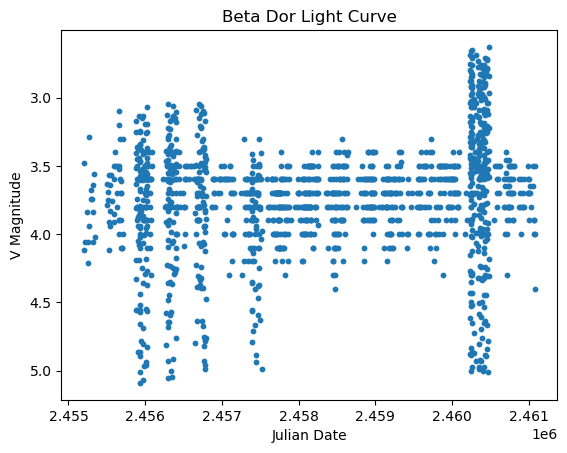

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

data = np.loadtxt("betador.txt", delimiter=',', skiprows=1, usecols=(0,1))

time = data[:,0]
mag = data[:,1]  

plt.figure()
plt.scatter(time, mag, s=10)
plt.gca().invert_yaxis()   
plt.xlabel("Julian Date")
plt.ylabel("V Magnitude")
plt.title("Beta Dor Light Curve")
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

data = np.genfromtxt(
    "betador.txt",
    delimiter=',',
    skip_header=1
)

time = data[:,0]
mag = data[:,1]
err = data[:,2]

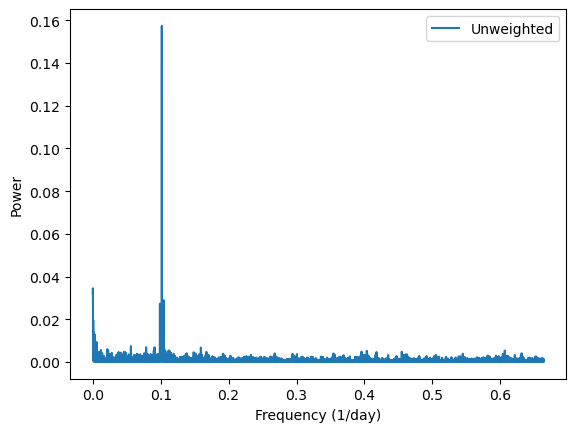

In [7]:
median_err = np.nanmedian(err)

err_filled = err.copy()
err_filled[np.isnan(err_filled)] = median_err

ls_weighted = LombScargle(time, mag, dy=err_filled)
frequency_w, power_weighted = ls_weighted.autopower()

ls_unweighted = LombScargle(time, mag)
frequency_u, power_unweighted = ls_unweighted.autopower()

plt.figure()
plt.plot(frequency_u, power_unweighted, label="Unweighted")
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

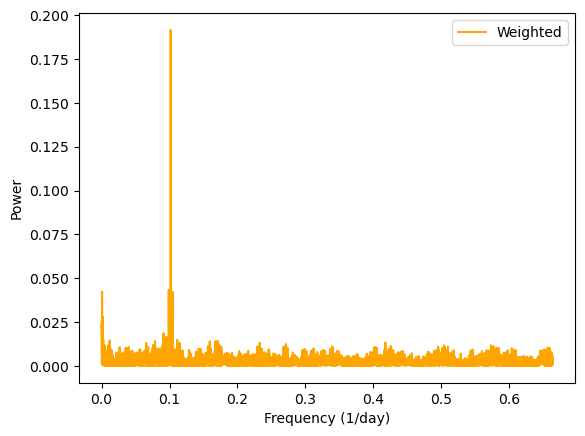

In [6]:
plt.figure()
plt.plot(frequency_w, power_weighted, label="Weighted", color='orange')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.show()

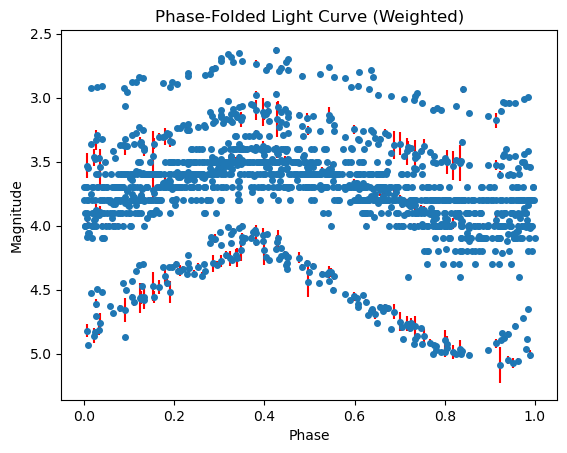

In [9]:
best_frequency = frequency_w[np.argmax(power_weighted)]
best_period = 1 / best_frequency

phase = (time % best_period) / best_period

plt.figure()
plt.errorbar(
    phase,
    mag,
    yerr=err_filled,
    fmt='o',
    markersize=4, ecolor='red')
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("Magnitude")
plt.title("Phase-Folded Light Curve (Weighted)")
plt.show()

In [11]:
best_freq_u = frequency_u[np.argmax(power_unweighted)]
best_freq_w = frequency_w[np.argmax(power_weighted)]

best_period_u = 1 / best_freq_u
best_period_w = 1 / best_freq_w

print("Unweighted period:", best_period_u)
print("Weighted period:", best_period_w)
print("Period difference:", best_period_w - best_period_u)

Unweighted period: 9.841062761506524
Weighted period: 9.844357944081949
Period difference: 0.0032951825754246045
